# Linear Regression Lab

In [1]:
from pyspark.sql import *
from pyspark.sql.functions import *
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import *
import pandas as pd

In [2]:
spark=SparkSession.builder.appName('House_Price_Prediction').master('local[*]').getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/14 12:21:37 WARN Utils: Your hostname, Samriddhas-Macbook-Air.local, resolves to a loopback address: 127.0.0.1; using 10.1.8.149 instead (on interface en0)
26/06/14 12:21:37 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/14 12:21:38 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/06/14 12:21:39 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


# Load data from SkLearn

In [3]:
from sklearn.datasets import fetch_california_housing

In [4]:
housing=fetch_california_housing()
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [5]:
df_pandas=pd.DataFrame(housing.data,columns=housing.feature_names)
df_pandas.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [6]:
df_pandas['MedHouseVal']=housing.target
df_pandas

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [7]:
df=spark.createDataFrame(df_pandas)
df.show(5)

[Stage 0:>                                                          (0 + 1) / 1]

+------+--------+------------------+------------------+----------+------------------+--------+---------+-----------+
|MedInc|HouseAge|          AveRooms|         AveBedrms|Population|          AveOccup|Latitude|Longitude|MedHouseVal|
+------+--------+------------------+------------------+----------+------------------+--------+---------+-----------+
|8.3252|    41.0| 6.984126984126984|1.0238095238095237|     322.0|2.5555555555555554|   37.88|  -122.23|      4.526|
|8.3014|    21.0| 6.238137082601054|0.9718804920913884|    2401.0| 2.109841827768014|   37.86|  -122.22|      3.585|
|7.2574|    52.0| 8.288135593220339| 1.073446327683616|     496.0|2.8022598870056497|   37.85|  -122.24|      3.521|
|5.6431|    52.0|5.8173515981735155|1.0730593607305936|     558.0| 2.547945205479452|   37.85|  -122.25|      3.413|
|3.8462|    52.0| 6.281853281853282|1.0810810810810811|     565.0|2.1814671814671813|   37.85|  -122.25|      3.422|
+------+--------+------------------+------------------+---------

Traceback (most recent call last):
  File "/opt/homebrew/opt/apache-spark/libexec/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
  File "/opt/homebrew/opt/apache-spark/libexec/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
    ~~~~~~~~~~~~~^^
BrokenPipeError: [Errno 32] Broken pipe
                                                                                

In [8]:
print(df.count())
print(len(df.columns))

20640
9


In [9]:
df.distinct().count()

df_clean=df.distinct()

df_clean.describe('AveRooms').show()

+-------+------------------+
|summary|          AveRooms|
+-------+------------------+
|  count|             20640|
|   mean|  5.42899974219036|
| stddev|2.4741731394243165|
|    min|0.8461538461538461|
|    max| 141.9090909090909|
+-------+------------------+



In [10]:
df_features=df_clean.withColumn(
    "RoomsPerHousehold",
    col('AveRooms') / col('AveBedrms')
).withColumn(
    "PopulationPerHousehold",
    col('Population')/col("AveOccup")
)

df_features.printSchema()

root
 |-- MedInc: double (nullable = true)
 |-- HouseAge: double (nullable = true)
 |-- AveRooms: double (nullable = true)
 |-- AveBedrms: double (nullable = true)
 |-- Population: double (nullable = true)
 |-- AveOccup: double (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- MedHouseVal: double (nullable = true)
 |-- RoomsPerHousehold: double (nullable = true)
 |-- PopulationPerHousehold: double (nullable = true)



In [11]:
feature_cols=[
    "MedInc","HouseAge","AveRooms","AveBedrms","Population","AveOccup","Latitude","Longitude","RoomsPerHousehold","PopulationPerHousehold"
]

target_col="MedHouseVal"

In [12]:
assembler=VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

df_assembler=assembler.transform(df_features)
df_assembler.show()

+------+--------+------------------+------------------+----------+------------------+--------+---------+-----------+------------------+----------------------+--------------------+
|MedInc|HouseAge|          AveRooms|         AveBedrms|Population|          AveOccup|Latitude|Longitude|MedHouseVal| RoomsPerHousehold|PopulationPerHousehold|            features|
+------+--------+------------------+------------------+----------+------------------+--------+---------+-----------+------------------+----------------------+--------------------+
|  3.12|    52.0| 4.797527047913447| 1.061823802163833|    1157.0|1.7882534775888717|   37.84|  -122.25|      2.414| 4.518195050946143|                 647.0|[3.12,52.0,4.7975...|
|7.0175|    37.0| 6.982954545454546|1.0284090909090908|     420.0|2.3863636363636362|   37.82|   -122.2|      3.667| 6.790055248618786|                 176.0|[7.0175,37.0,6.98...|
|5.8948|    52.0| 7.740088105726873|1.0837004405286343|     585.0|2.5770925110132157|   37.83|  -122

In [13]:
scaler=StandardScaler(
    inputCol="features",
    outputCol="sacledFeatures",
    withMean=True,
    withStd=True
)

scaler_model=scaler.fit(df_assembler)
df_scaled=scaler_model.transform(df_assembler)

In [14]:
train_df,test_df=df_scaled.randomSplit([0.8,0.2],seed=42)

In [15]:
train_df.count()

16560

# Model Training using Linear Regression

In [16]:
lr=LinearRegression(
    featuresCol="sacledFeatures",
    labelCol=target_col,
    maxIter=100,
    regParam=0.01
)

lr_model=lr.fit(train_df)
lr_model.intercept

26/06/14 12:22:03 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/06/14 12:22:04 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/06/14 12:22:04 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


2.069442704331473

In [17]:
coefficients=lr_model.coefficients

for i in range (len(feature_cols)):
    feature=feature_cols[i]
    coeff=coefficients[i]
    print(feature+":"+str(coeff))

MedInc:0.8528782026322592
HouseAge:0.150765681378952
AveRooms:0.17387959670266204
AveBedrms:-0.09034084316200919
Population:-0.3996773617500328
AveOccup:-0.0005009738414273203
Latitude:-0.7676491854027109
Longitude:-0.7244544789338914
RoomsPerHousehold:-0.24404296339770418
PopulationPerHousehold:0.44892091239636595


In [18]:
lr_predictions=lr_model.transform(test_df)
lr_predictions.printSchema()

root
 |-- MedInc: double (nullable = true)
 |-- HouseAge: double (nullable = true)
 |-- AveRooms: double (nullable = true)
 |-- AveBedrms: double (nullable = true)
 |-- Population: double (nullable = true)
 |-- AveOccup: double (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- MedHouseVal: double (nullable = true)
 |-- RoomsPerHousehold: double (nullable = true)
 |-- PopulationPerHousehold: double (nullable = true)
 |-- features: vector (nullable = true)
 |-- sacledFeatures: vector (nullable = true)
 |-- prediction: double (nullable = false)



In [19]:
lr_predictions.select('prediction').show(5)

+------------------+
|        prediction|
+------------------+
|0.6648682253413054|
|0.8896051628491979|
|1.1357381071441537|
|0.4911399466802462|
|0.9331499479322523|
+------------------+
only showing top 5 rows


In [20]:
lr_with_error=lr_predictions.withColumn(
    "Error",
    col(target_col)-col('prediction')
)

In [21]:
lr_with_error.printSchema()

root
 |-- MedInc: double (nullable = true)
 |-- HouseAge: double (nullable = true)
 |-- AveRooms: double (nullable = true)
 |-- AveBedrms: double (nullable = true)
 |-- Population: double (nullable = true)
 |-- AveOccup: double (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- MedHouseVal: double (nullable = true)
 |-- RoomsPerHousehold: double (nullable = true)
 |-- PopulationPerHousehold: double (nullable = true)
 |-- features: vector (nullable = true)
 |-- sacledFeatures: vector (nullable = true)
 |-- prediction: double (nullable = false)
 |-- Error: double (nullable = true)



In [22]:
lr_with_error.select(
    col(target_col).alias('Actual Price'),
    col('prediction').alias('Predicted'),
    col('Error').alias('Residuals')
).show(10)

+------------+------------------+--------------------+
|Actual Price|         Predicted|           Residuals|
+------------+------------------+--------------------+
|       0.735|0.6648682253413054| 0.07013177465869458|
|       1.625|0.8896051628491979|  0.7353948371508021|
|       0.675|1.1357381071441537|-0.46073810714415364|
|       1.625|0.4911399466802462|  1.1338600533197538|
|       0.875|0.9331499479322523|-0.05814994793225...|
|       1.113|0.7276692982496091| 0.38533070175039086|
|       1.344|   0.9888095412741| 0.35519045872590005|
|       1.042|0.9057365015068561|  0.1362634984931439|
|       0.818|1.0195557534607709|-0.20155575346077093|
|       1.531|0.5739967159084014|  0.9570032840915985|
+------------+------------------+--------------------+
only showing top 10 rows


In [23]:
evaluator_r2=RegressionEvaluator(labelCol=target_col,predictionCol="prediction",metricName="r2")
### rmse,mae

lm_r2=evaluator_r2.evaluate(lr_predictions)
print(lm_r2)

0.6454736092562389


In [24]:
import matplotlib.pyplot as plt

lr_pred_pandas=lr_predictions.select(
    col(target_col).alias('Actual'),
    col('prediction').alias('Predicted')
).toPandas()

lr_pred_pandas

,Actual,Predicted
0,0.73500,0.664868
1,1.62500,0.889605
2,0.67500,1.135738
3,1.62500,0.491140
4,0.87500,0.933150
...,...,...
4075,5.00001,6.832841
4076,5.00001,6.631838
4077,1.31300,7.237605
4078,5.00001,6.937296


In [25]:
import PIL
print(PIL.__version__)

12.2.0


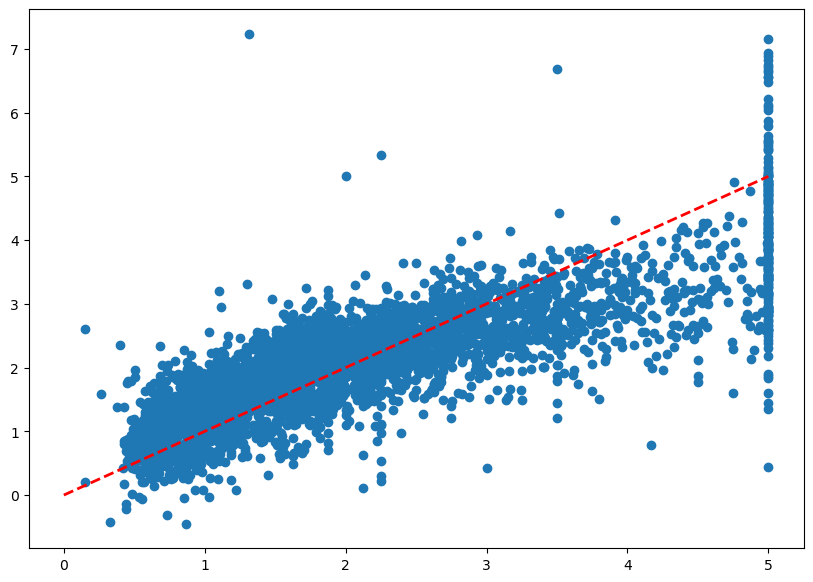

In [26]:
fig,ax=plt.subplots(figsize=(10,7))
ax.scatter(lr_pred_pandas['Actual'],lr_pred_pandas['Predicted'])
ax.plot([0,5],[0,5],'r--',lw=2)
plt.show()

# Implement Random Forest Regressor